In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

df = pd.read_csv(r"C:\Users\김양일\Desktop\Team_Project\data\processed\02_의료기관1_v3.csv")

print(df.head())

    지역  65세이상  고령인구비율  의료기관수  공공 기관 수
0   동면   1020   54.72      0        2
1  수신면    946   47.73      0        2
2  성남면   1328   48.57      0        3
3  광덕면   1857   47.01      0        3
4  일봉동   4144   17.11      1        0


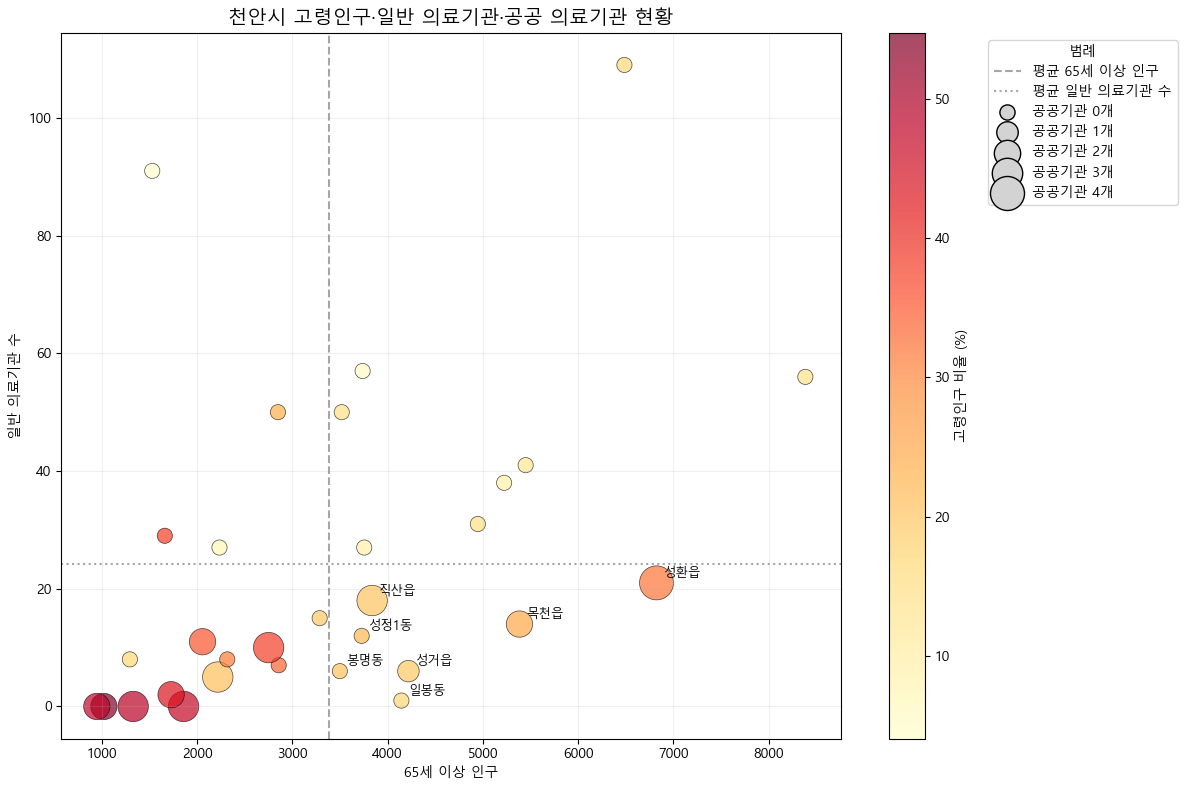

In [5]:
matplotlib.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

bubble_df = df[
    [
        "지역",
        "65세이상",
        "고령인구비율",
        "의료기관수",
        "공공 기관 수"
    ]
].copy()

avg_old = bubble_df["65세이상"].mean()
avg_med = bubble_df["의료기관수"].mean()

bubble_size = (bubble_df["공공 기관 수"] + 1) * 120

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    bubble_df["65세이상"],          
    bubble_df["의료기관수"],        
    s=bubble_size,                  
    c=bubble_df["고령인구비율"],    
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidth=0.5
)

plt.axvline(
    avg_old,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="평균 65세 이상 인구"
)

plt.axhline(
    avg_med,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="평균 일반 의료기관 수"
)

priority_mask = (
    (bubble_df["65세이상"] >= avg_old) &
    (bubble_df["의료기관수"] < avg_med)
)

priority_df = bubble_df[priority_mask]

for _, row in priority_df.iterrows():
    plt.text(
        row["65세이상"] + 70,
        row["의료기관수"] + 1,
        row["지역"],
        fontsize=9
    )

colorbar = plt.colorbar(scatter)
colorbar.set_label("고령인구 비율 (%)")

for count in [0, 1, 2, 3, 4]:
    plt.scatter(
        [],
        [],
        s=(count + 1) * 120,
        color="lightgray",
        edgecolors="black",
        label=f"공공기관 {count}개"
    )


plt.title(
    "천안시 고령인구·일반 의료기관·공공 의료기관 현황",
    fontsize=14
)
plt.xlabel("65세 이상 인구")
plt.ylabel("일반 의료기관 수")

plt.grid(alpha=0.2)
plt.legend(
    title="범례",
    bbox_to_anchor=(1.18, 1),
    loc="upper left"
)

plt.tight_layout()


plt.savefig(
    "천안시 고령인구·일반 의료기관·공공 의료기관 현황.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()